# Lab 01 - Numerical Calculus (Python)

Solutions for the exercises from `L1_NC.pdf`, implemented in Python notebooks.

We use:
- `numpy` for numerical work
- `matplotlib` for plots
- `fractions.Fraction` (optional exercise) for exact rational values

> Note: even if the PDF mentions MATLAB, everything below is in Python.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction

# Optional: slightly nicer default plot style
plt.style.use('seaborn-v0_8-whitegrid')

Matplotlib is building the font cache; this may take a moment.


## Exercise 1

Given
$$
p(x) = x^5 - 5x^4 - 16x^3 + 16x^2 - 17x + 21
$$

Tasks:
1. Plot on $[-4, 7.2]$
2. Compute $p(-2.5)$
3. Find the roots of $p$

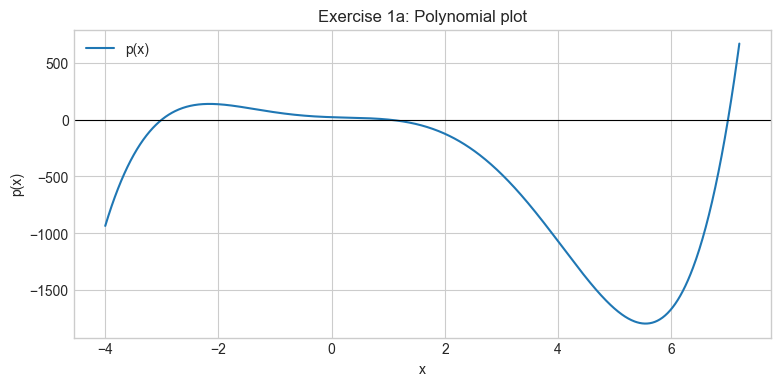

p(-2.5) = 120.53125
Roots of p(x):
(7+0j)
(-2.9999999999999987+0j)
(0.9999999999999992+0j)
(1.0636107595153457e-16+0.9999999999999994j)
(1.0636107595153457e-16-0.9999999999999994j)


In [2]:
# Coefficients for p(x) = x^5 - 5x^4 - 16x^3 + 16x^2 - 17x + 21
coeffs = [1, -5, -16, 16, -17, 21]

# a) Plot p on [-4, 7.2]
x = np.linspace(-4, 7.2, 1000)
y = np.polyval(coeffs, x)

plt.figure(figsize=(9, 4))
plt.plot(x, y, label='p(x)')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Exercise 1a: Polynomial plot')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.show()

# b) Compute p(-2.5)
p_at_minus_2_5 = np.polyval(coeffs, -2.5)
print(f'p(-2.5) = {p_at_minus_2_5}')

# c) Roots
roots = np.roots(coeffs)
print('Roots of p(x):')
for r in roots:
    print(r)

## Exercise 2

Plot on $[0, 2\pi]$:
- $f(x)=\sin x$
- $g(x)=\sin 2x$
- $h(x)=\sin 3x$

Both:
1. on the same figure, and
2. in three stacked tiles.

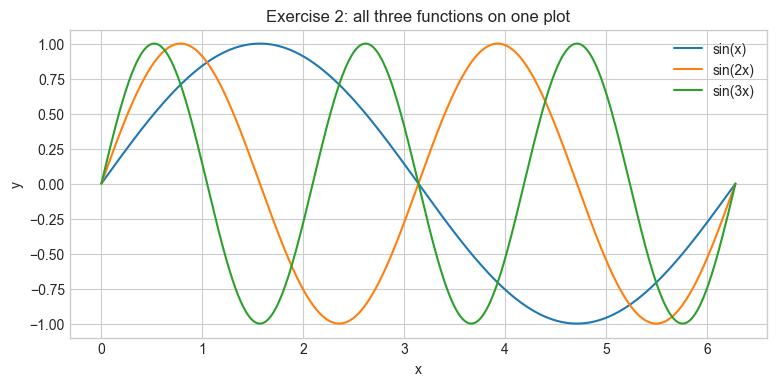

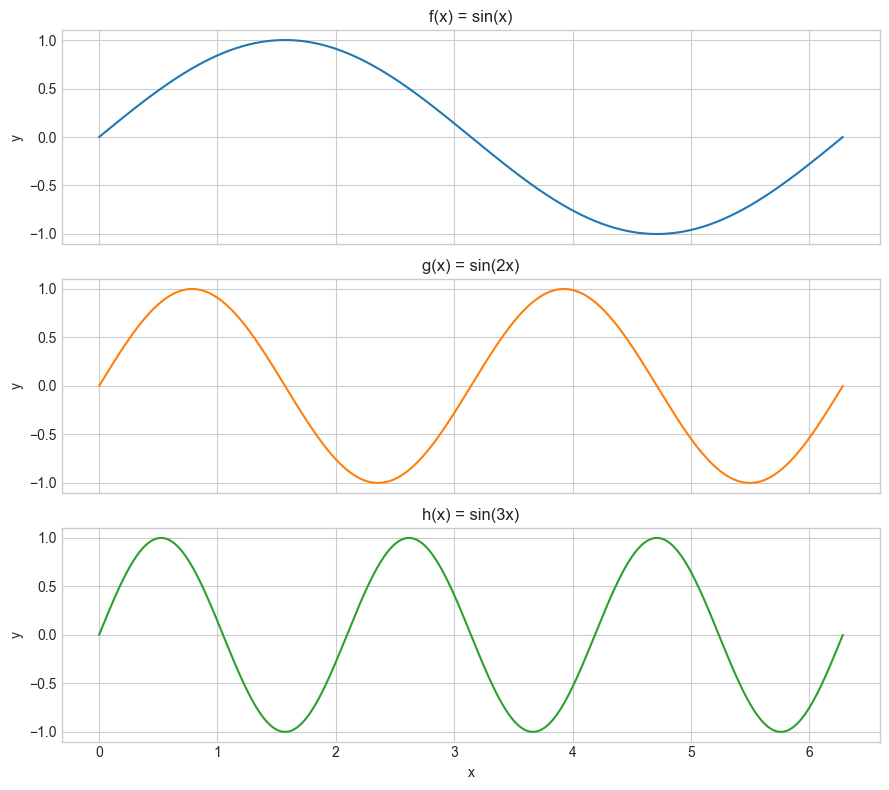

In [3]:
x = np.linspace(0, 2 * np.pi, 1000)
f = np.sin(x)
g = np.sin(2 * x)
h = np.sin(3 * x)

# Same figure
plt.figure(figsize=(9, 4))
plt.plot(x, f, label='sin(x)')
plt.plot(x, g, label='sin(2x)')
plt.plot(x, h, label='sin(3x)')
plt.title('Exercise 2: all three functions on one plot')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# Three stacked tiles
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
axes[0].plot(x, f, color='tab:blue')
axes[0].set_title('f(x) = sin(x)')
axes[1].plot(x, g, color='tab:orange')
axes[1].set_title('g(x) = sin(2x)')
axes[2].plot(x, h, color='tab:green')
axes[2].set_title('h(x) = sin(3x)')
axes[2].set_xlabel('x')
for ax in axes:
    ax.set_ylabel('y')
plt.tight_layout()
plt.show()

## Exercise 3

Epicycloid (hypercycloid) with
$$
\begin{aligned}
x(t) &= (R+r)\cos t - r\cos\left(\left(\frac{R}{r}+1\right)t\right), \\
y(t) &= (R+r)\sin t - r\sin\left(\left(\frac{R}{r}+1\right)t\right),
\end{aligned}
$$
for $t \in [0, 10\pi]$, $R=3.8$, $r=1$.

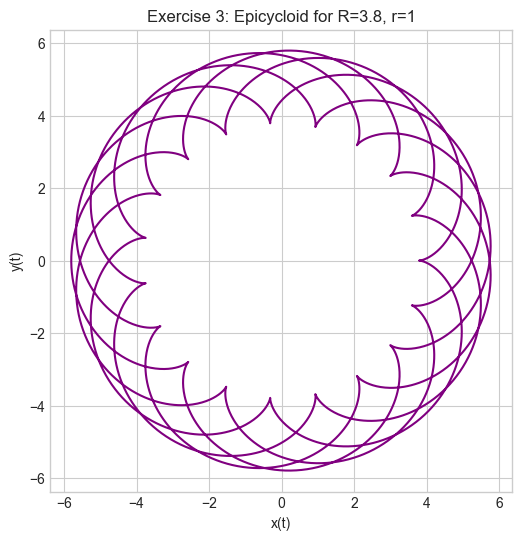

In [4]:
R = 3.8
r = 1.0

t = np.linspace(0, 10 * np.pi, 4000)
k = R / r + 1

x = (R + r) * np.cos(t) - r * np.cos(k * t)
y = (R + r) * np.sin(t) - r * np.sin(k * t)

plt.figure(figsize=(6, 6))
plt.plot(x, y, color='purple')
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Exercise 3: Epicycloid for R=3.8, r=1')
plt.xlabel('x(t)')
plt.ylabel('y(t)')
plt.show()

## Exercise 4

For
$$
f(x,y) = \sin(e^x)\cos(\ln y), \quad (x,y)\in[-2,2]\times[0.5,4.5],
$$
plot using:
1. a mesh-like 3D wireframe
2. a `plot3`-style 3D line rendering (grid lines).

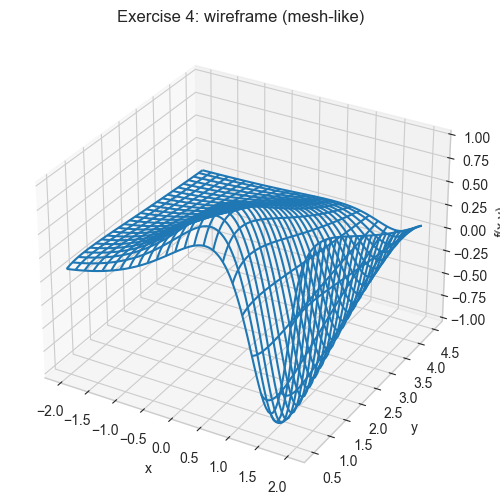

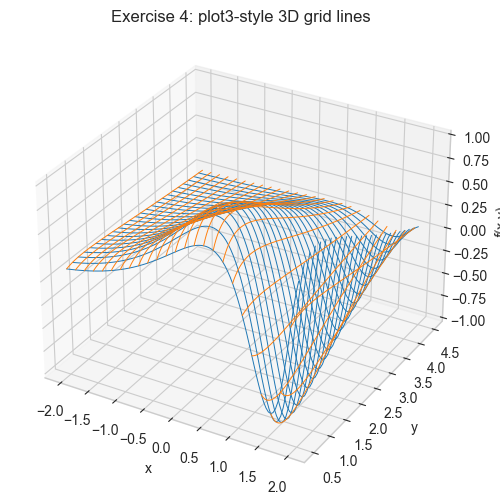

In [5]:
x = np.linspace(-2, 2, 100)
y = np.linspace(0.5, 4.5, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.exp(X)) * np.cos(np.log(Y))

# 1) Mesh-like wireframe
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_wireframe(X, Y, Z, rstride=4, cstride=4)
ax.set_title('Exercise 4: wireframe (mesh-like)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
plt.show()

# 2) plot3-style: draw 3D lines along grid directions
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for i in range(0, X.shape[0], 4):
    ax.plot3D(X[i, :], Y[i, :], Z[i, :], color='tab:blue', linewidth=0.7)
for j in range(0, X.shape[1], 4):
    ax.plot3D(X[:, j], Y[:, j], Z[:, j], color='tab:orange', linewidth=0.7)

ax.set_title('Exercise 4: plot3-style 3D grid lines')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
plt.show()

## Exercise 5 (Optional)

Compute the continued fraction
$$
f(n)=1+\cfrac{1}{1+\cfrac{1}{1+\cdots}}
$$
with `n` nested fractions, for `n = 3, 10, 100, 2026`, and observe the trend.

In [6]:
def continued_fraction(n: int) -> Fraction:
    """Return exact f(n) as a Fraction."""
    value = Fraction(1, 1)  # f(0)
    for _ in range(n):
        value = 1 + Fraction(1, value)
    return value

for n in [3, 10, 100, 2026]:
    v = continued_fraction(n)
    print(f'n={n:4d}: exact={v}  ~= {float(v):.16f}')

phi = (1 + np.sqrt(5)) / 2
print(f'golden ratio phi ~= {phi:.16f}')
print('Observation: f(n) converges to phi as n grows.')

n=   3: exact=5/3  ~= 1.6666666666666667
n=  10: exact=144/89  ~= 1.6179775280898876
n= 100: exact=927372692193078999176/573147844013817084101  ~= 1.6180339887498949
n=2026: exact=3002267775230296425969962152049160599592155816397045007565723147384278246442690387798263415634728948083315060630566562887911829863830408282920315750584419181806027912901936883715893840331634380213425117758859216373659414592517035212344155694378240985697378604226889975567952764362886766468757091913163889630520022031761087440321755589125863244216786178722041597442589748761568163012167636233827291640832198962677449737649936/18555035284208528561402082404400266228933252101484685346189827541051596215123644304513977579911270123595137867092271100175228553907391529538090216608897063460338932676028176589957598847879517455352603584559293188919340489188559805358351741741525852702445670388600474978564235806871336002582130932934257808879902186903257008359464558305261958667727676247288361950550377923468021554625902733675729